In [25]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
df=sns.load_dataset("healthexp")
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [26]:
df.columns

Index(['Year', 'Country', 'Spending_USD', 'Life_Expectancy'], dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


In [28]:
df.nunique()

Year                51
Country              6
Spending_USD       274
Life_Expectancy    118
dtype: int64

In [29]:
df["Country"].unique()

<StringArray>
['Germany', 'France', 'Great Britain', 'Japan', 'USA', 'Canada']
Length: 6, dtype: str

## Phase 1 : Étapes pratiques détaillées
## Question 1 : Analysez la variable "Country"

In [30]:
df["Country"].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

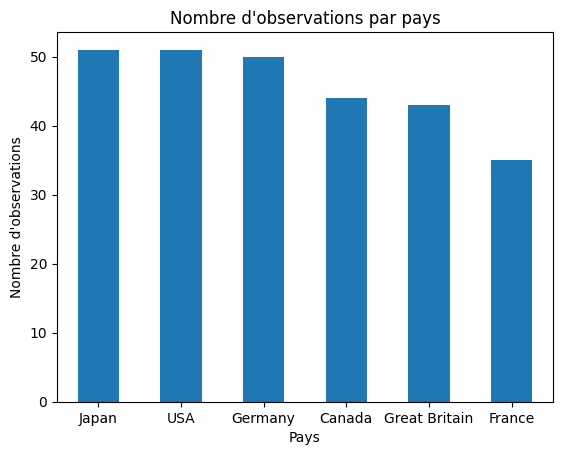

In [31]:
df["Country"].value_counts().plot(kind="bar")
plt.title("Nombre d'observations par pays")
plt.xlabel("Pays")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

## Question 2 : Analysez la variable "Spending_USD"

In [32]:
df["Spending_USD"].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

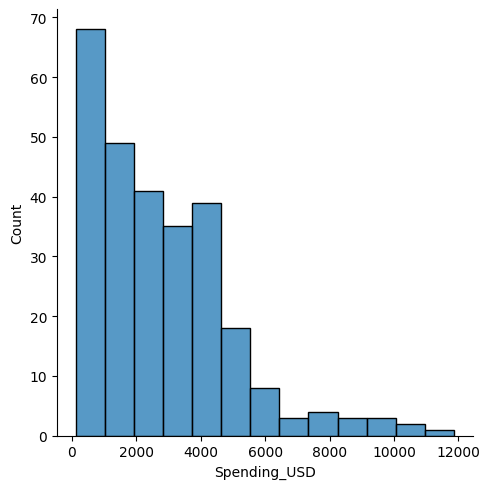

In [33]:
sns.displot(data=df, x="Spending_USD")

<Axes: xlabel='Spending_USD'>

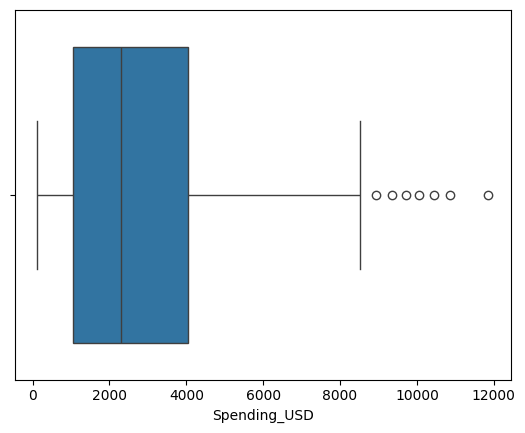

In [34]:
sns.boxplot(data=df, x="Spending_USD")

## Question 3 : Evolution de Life_Expectancy dans le temps

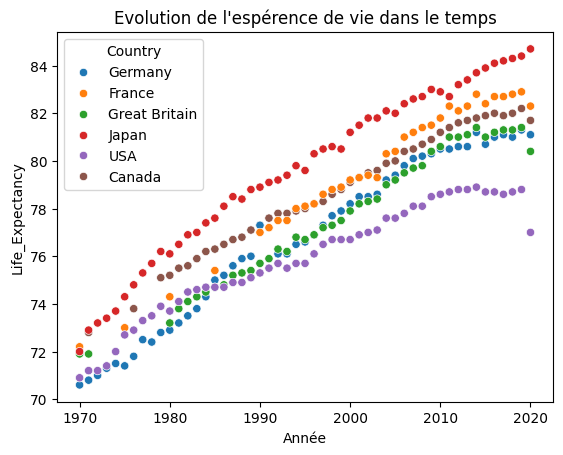

In [35]:
plt.Figure(figsize=(10,6))

sns.scatterplot(data=df, x="Year", y="Life_Expectancy", hue="Country")

plt.title("Evolution de l'espérence de vie dans le temps")
plt.xlabel("Année")
plt.ylabel("Life_Expectancy")
plt.show()

## Question 4 : Evolution des dépenses : allemagne vs Grande-bretagne

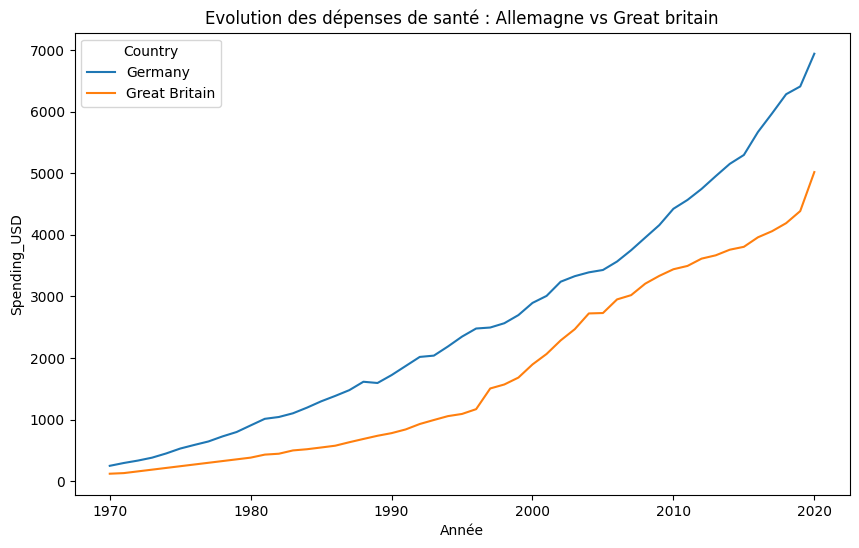

In [36]:
plt.figure(figsize=(10,6))
df_filtered = df[df["Country"].isin(["Germany","Great Britain"])]

sns.lineplot(data=df_filtered, x="Year", y="Spending_USD", hue="Country")

plt.title("Evolution des dépenses de santé : Allemagne vs Great britain")
plt.xlabel("Année")
plt.ylabel("Spending_USD")
plt.show()


## Question 5 : Analyse de Life_Expectancy par pays

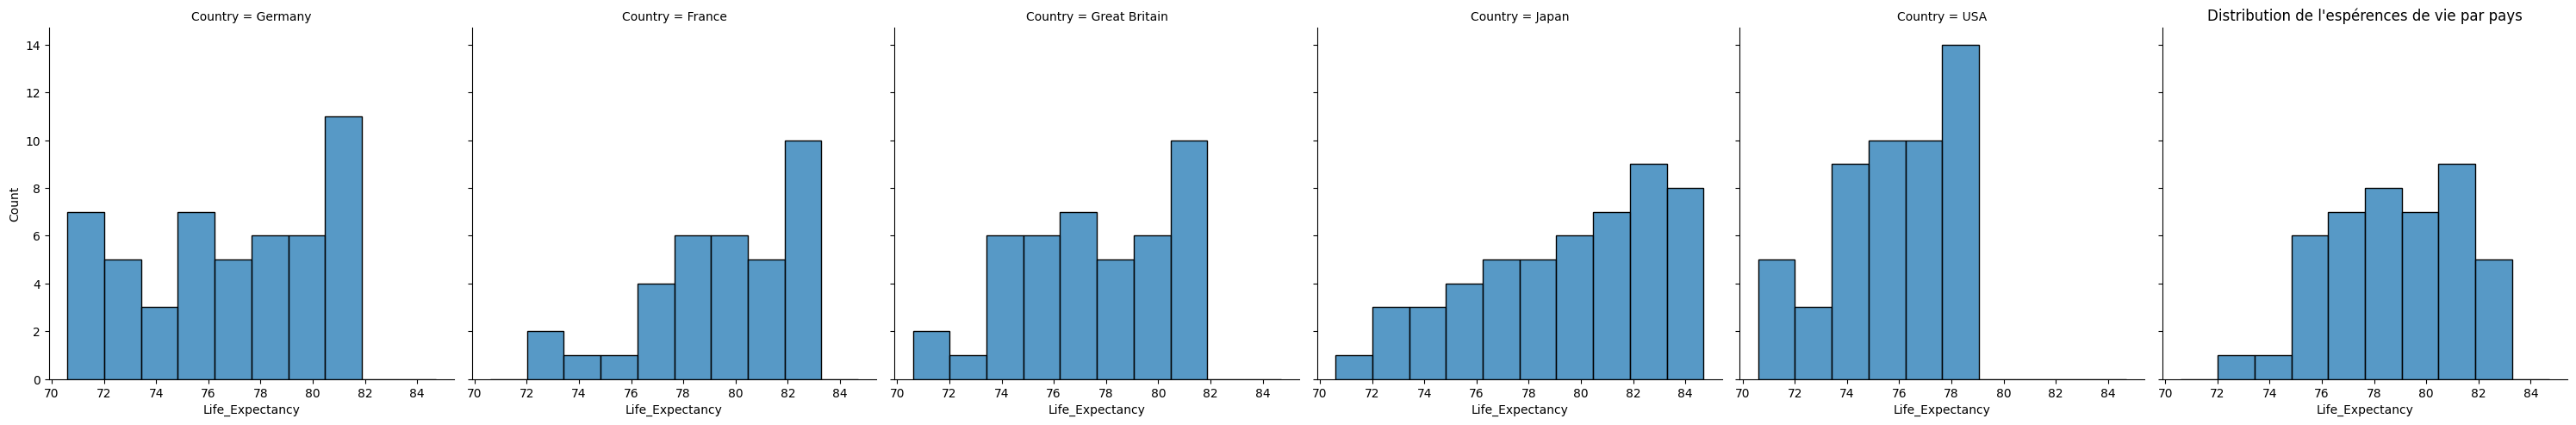

In [37]:
#Histogramme
df.groupby("Country")["Life_Expectancy"].describe()
sns.displot(data=df, x="Life_Expectancy", col="Country")

plt.title("Distribution de l'espérences de vie par pays")
plt.show()


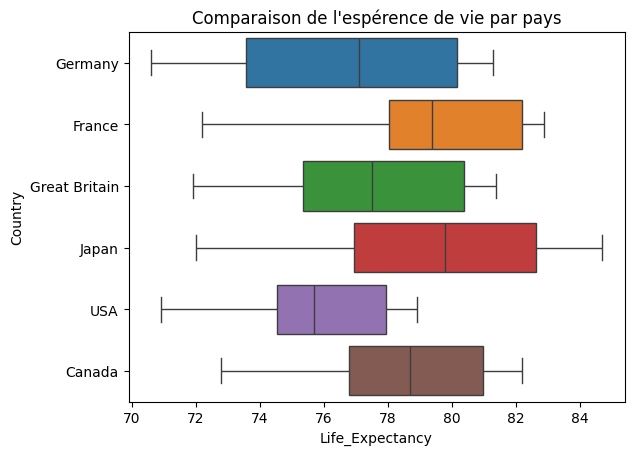

In [38]:
sns.boxplot(data=df, x="Life_Expectancy", y="Country", hue="Country")
plt.title("Comparaison de l'espérence de vie par pays")
plt.show()

## Question 6 : Relation entre Spending_USD et Life_Expectancy (USA 2000-2020)

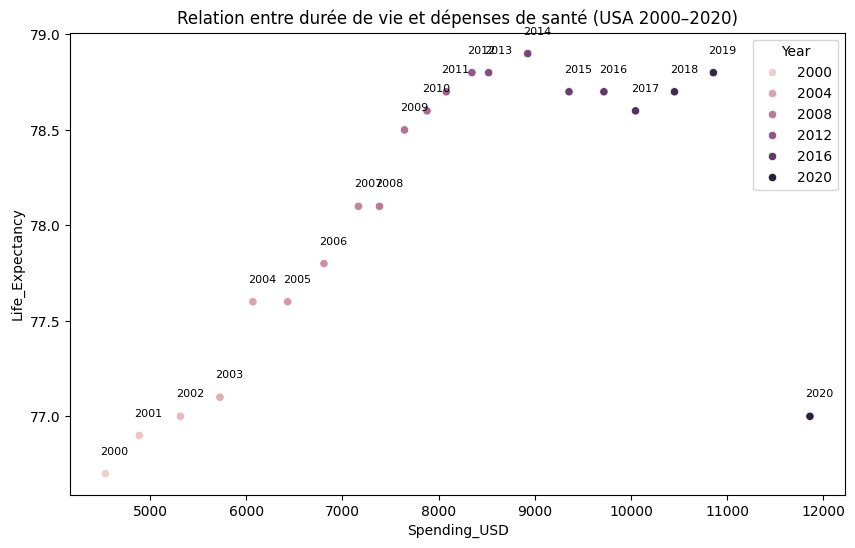

In [39]:
USA = df[(df["Country"] == "USA") & 
         (df["Year"] >= 2000) & 
         (df["Year"] <= 2020)]

plt.figure(figsize=(10,6))

sns.scatterplot(data=USA, x="Spending_USD", y="Life_Expectancy", hue="Year")

plt.title("Relation entre durée de vie et dépenses de santé (USA 2000–2020)")

for i in range(len(USA)):
    plt.text(
        USA["Spending_USD"].iloc[i] - 50 ,
        USA["Life_Expectancy"].iloc[i]+ 0.1 ,
        str(USA["Year"].iloc[i]),
        fontsize=8
    )

plt.show()

## Phase 2 : Analyses statistiques avancées
## Question 1 : La corrélation de Pearson entre ces deux variables aux Etats-Unis (2000-2020).

In [40]:
from scipy.stats import pearsonr
df_USA = df[(df["Country"] == "USA") & (df["Year"].between(2000, 2020))]

corr, p_value = pearsonr(df_USA["Spending_USD"], df_USA["Life_Expectancy"])

print("Corrélation de Pearson :", corr)
print("p-value :", p_value) 

Corrélation de Pearson : 0.6210674528998253
p-value : 0.0026581544805799064


## (Bonus) : Test d’hypothèse sur la durée de vie aux États-Unis


In [41]:

# Filtrer USA
df_usa = df[df["Country"] == "United States"].sort_values("Year")

# Diff annuelle
df_usa["diff"] = df_usa["Life_Expectancy"].diff()

# حذف NaN
diff_values = df_usa["diff"].dropna()

# Test
t_stat, p_value = ttest_1samp(diff_values, 0.3)

print("p-value =", p_value)

p-value = nan


C:\Users\lenovo\AppData\Local\Temp\ipykernel_1872\3920624302.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = ttest_1samp(diff_values, 0.3)


##  Phase 3 – Application – Dataset MPG


##  Question 1 : les variables discrètes et continues de ce dataset

In [ ]:
import pandas as pd 
import matplotlib as plt
import seaborn as sns 

df= sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [47]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='str')

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


## Question 2 : Analyse de la variable MPG

In [48]:
df["mpg"].mean()

np.float64(23.514572864321607)

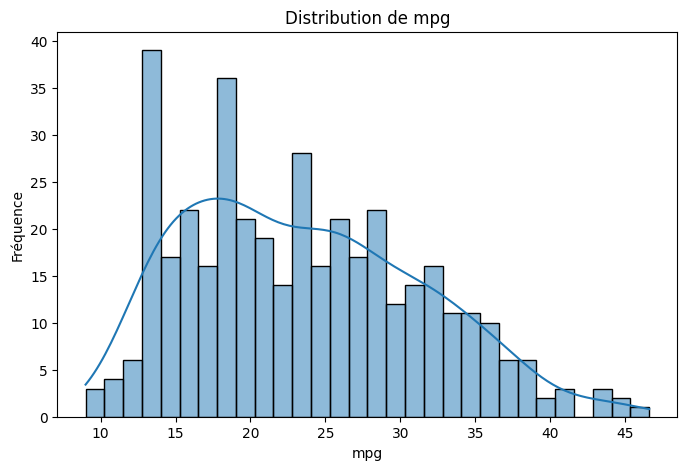

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], bins=30, kde=True)

plt.title("Distribution de mpg")
plt.xlabel("mpg")
plt.ylabel("Fréquence")

plt.show()

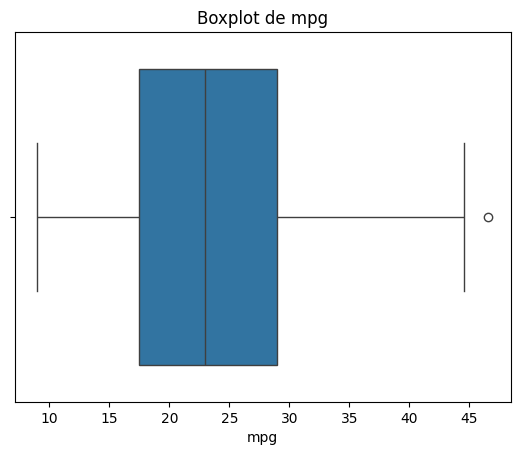

In [53]:
plt.Figure(figsize=(6,4))
sns.boxplot(x=df["mpg"])

plt.title("Boxplot de mpg")
plt.show()

## Question 3 : Analyse de la variable Cylindre

In [54]:
df["cylinders"].unique()

array([8, 4, 6, 3, 5])

In [55]:
df["cylinders"].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

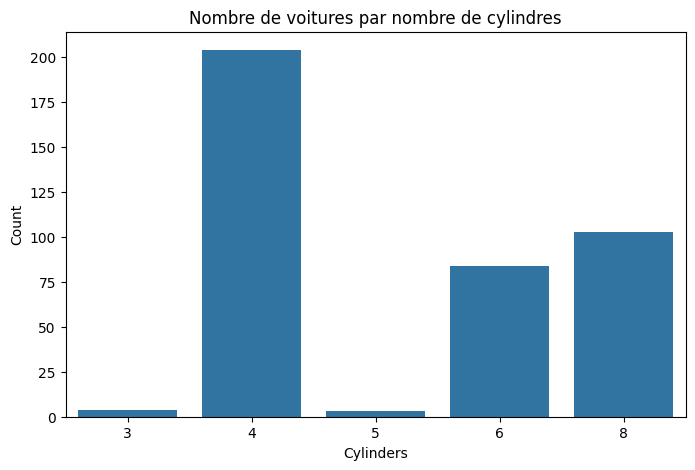

In [59]:
plt.figure(figsize=(8,5))

sns.countplot(x="cylinders", data=df)

plt.title("Nombre de voitures par nombre de cylindres")
plt.xlabel("Cylinders")
plt.ylabel("Count")

plt.show()

## Question 4 : Analyse de variable origin 

In [60]:
df["origin"].unique()

<StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str

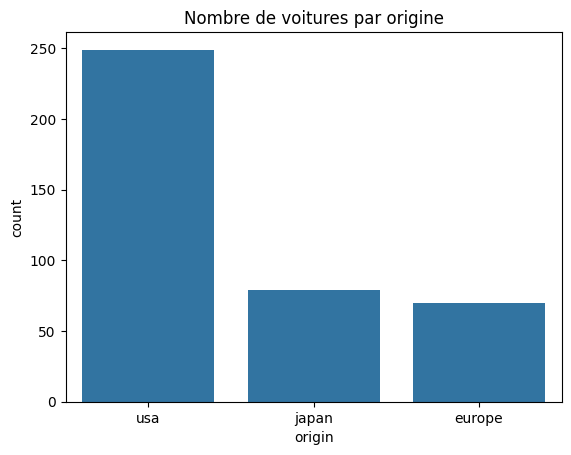

In [62]:
plt.Figure(figsize=(8,5))
sns.countplot(data=df, x="origin")
plt.title("Nombre de voitures par origine")
plt.xlabel("origin")
plt.ylabel("count")
plt.show()

## Question 5 : l'évolution de la consommation des voitures (mpg) par rapport au nombre de chevaux (horsepower)

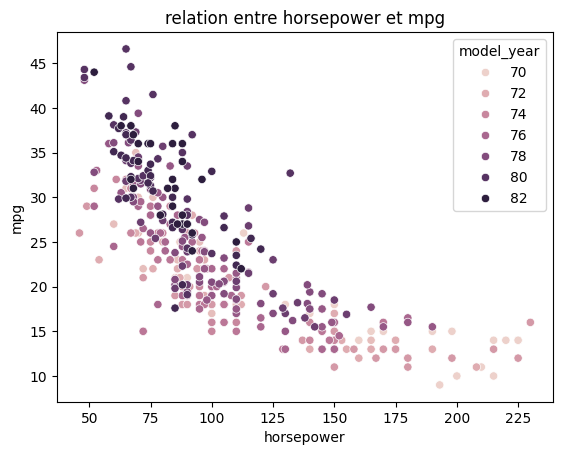

In [71]:
plt.Figure(figsize=(8,5))
sns.scatterplot(data=df, x="horsepower", y="mpg",hue="model_year")
plt.title("relation entre horsepower et mpg")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.show()

## Question 6 :  l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82.

model_year
70    3716.500000
71    3401.600000
72    3682.666667
73    3821.448276
74    3503.333333
75    3533.200000
76    3405.409091
77    3422.000000
78    3141.136364
79    3210.217391
80    2822.428571
81    2695.000000
82    2637.750000
Name: weight, dtype: float64


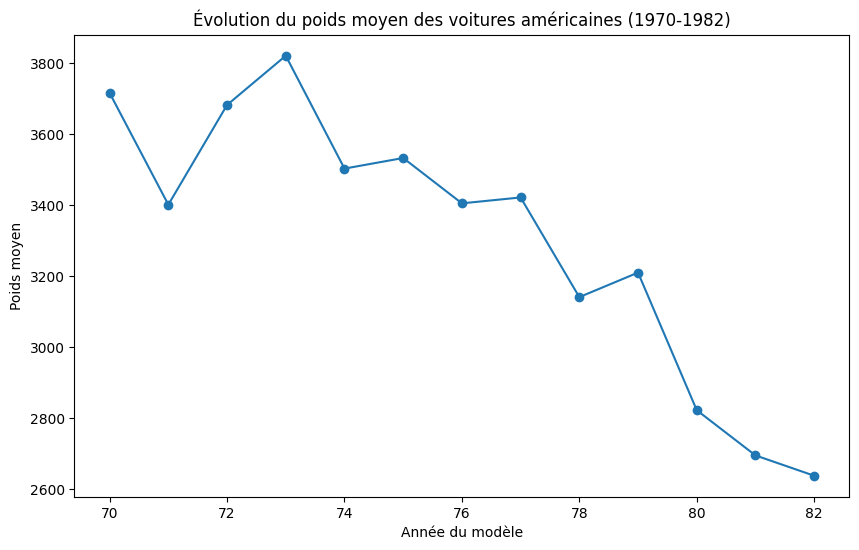

In [73]:
df_usa = df[df["origin"] == "usa"]

df_weight = df_usa.groupby("model_year")["weight"].mean()

print(df_weight)

plt.figure(figsize=(10,6))
df_weight.plot(marker="o")

plt.title("Évolution du poids moyen des voitures américaines (1970-1982)")
plt.xlabel("Année du modèle")
plt.ylabel("Poids moyen")
plt.show()

## Question 7 : Relation entre cylinders et model_year

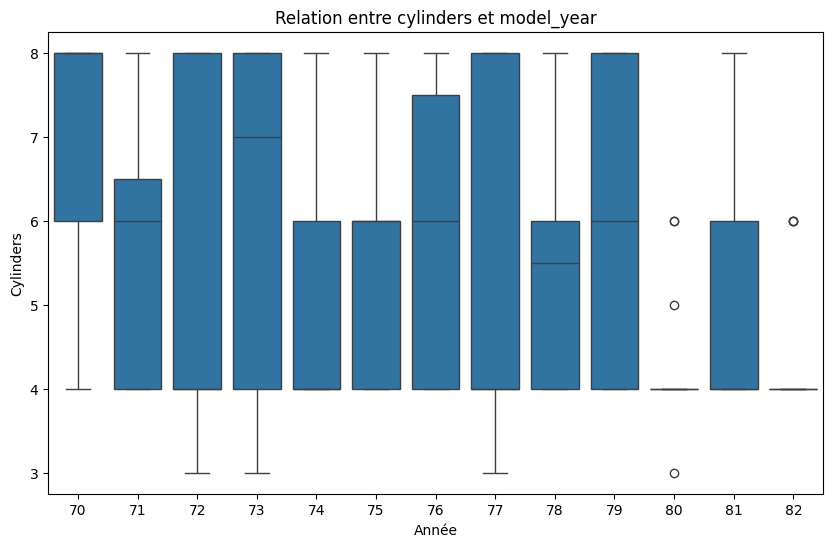

In [76]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="model_year", y="cylinders")

plt.title("Relation entre cylinders et model_year")
plt.xlabel("Année")
plt.ylabel("Cylinders")

plt.show()

## Question 8 : Analysez la relation entre le nombre de cylindres et l'origine.

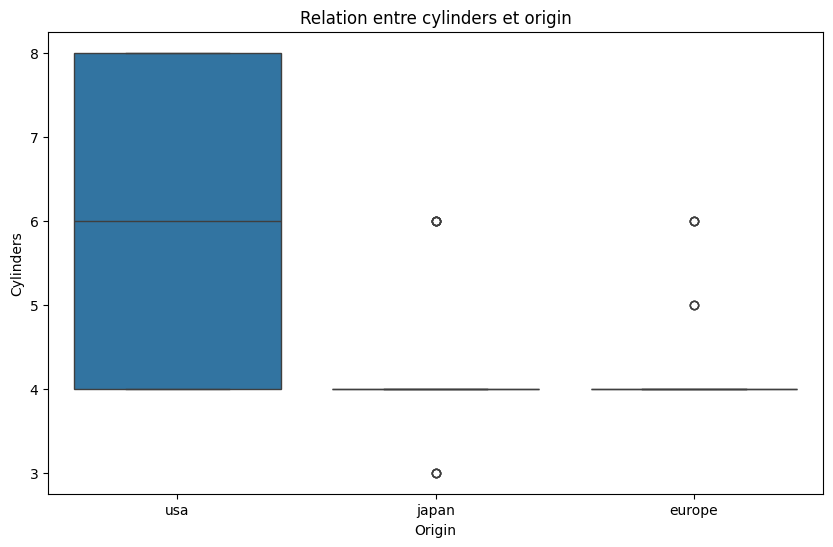

In [80]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="origin", y="cylinders")

plt.title("Relation entre cylinders et origin")
plt.xlabel("Origin")
plt.ylabel("Cylinders")

plt.show()

## Quelle est l'accélération moyenne des voitures des différents pays ?

In [81]:
df.groupby("origin")["acceleration"].mean()

origin
europe    16.787143
japan     16.172152
usa       15.033735
Name: acceleration, dtype: float64

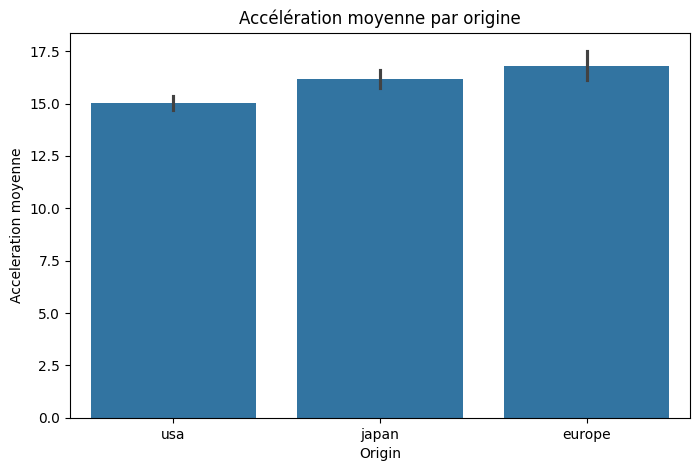

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="origin", y="acceleration")

plt.title("Accélération moyenne par origine")
plt.xlabel("Origin")
plt.ylabel("Acceleration moyenne")

plt.show()

## Quelle est-elle pour les modèles de l'année 80 ?

In [83]:
df_80 = df[df["model_year"] == 80]

df_80.groupby("origin")["acceleration"].mean()

origin
europe    18.366667
japan     16.015385
usa       16.800000
Name: acceleration, dtype: float64

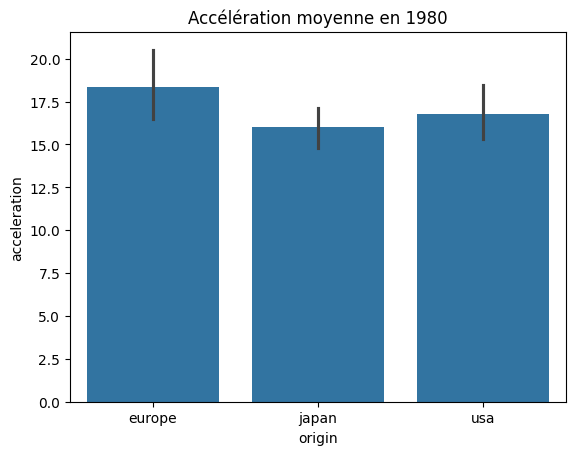

In [84]:
sns.barplot(data=df_80, x="origin", y="acceleration")
plt.title("Accélération moyenne en 1980")
plt.show()